<a href="https://colab.research.google.com/github/Nachos-mic/Lung_CT_Diagnostic_ML/blob/main/Lung_Diagnostics_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Biblioteki


In [1]:
!pip install -q grad-cam

In [2]:
!pip install -q optuna

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from PIL import Image
from google.colab import drive
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import time
import copy
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torch.utils.data import WeightedRandomSampler
import optuna
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, accuracy_score
import random
import torch.nn.functional as F
import cv2
import json


MERGED_STAGE_TO_LABEL = {
    'I': 0,
    'II': 1,
    'IIIa': 2,
    'IIIb': 2,
    'III': 2,
}
LABEL_TO_MERGED_STAGE = {
    0: 'I',
    1: 'II',
    2: 'III',
}
NUM_CLASSES = len(LABEL_TO_MERGED_STAGE)


def merge_stage_label(value):
    if pd.isna(value):
        raise ValueError('Missing stage or label value')

    if isinstance(value, str):
        normalized = value.strip()
        if normalized in MERGED_STAGE_TO_LABEL:
            return MERGED_STAGE_TO_LABEL[normalized]
        return 2 if normalized == 'III' else int(normalized)

    return 2 if int(value) == 3 else int(value)


Rozpakowanie danych do dysku (jednorazowe)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

#Tworzenie folderu z danymi
!mkdir -p /content/dataset
!unzip -q "/content/drive/MyDrive/lung_dataset.zip" -d "/content/dataset"
print("Dane rozpakowane pomyślnie!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
replace /content/dataset/data_2d_full_slices/LUNG1-001_slice_0060.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
Dane rozpakowane pomyślnie!


EDA dla datasetu - statystyki klas i wizualizacja przykładowych slice'ów

/tmp/ipykernel_13502/566853590.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='merged_stage', order=['I', 'II', 'III'], palette='viridis')


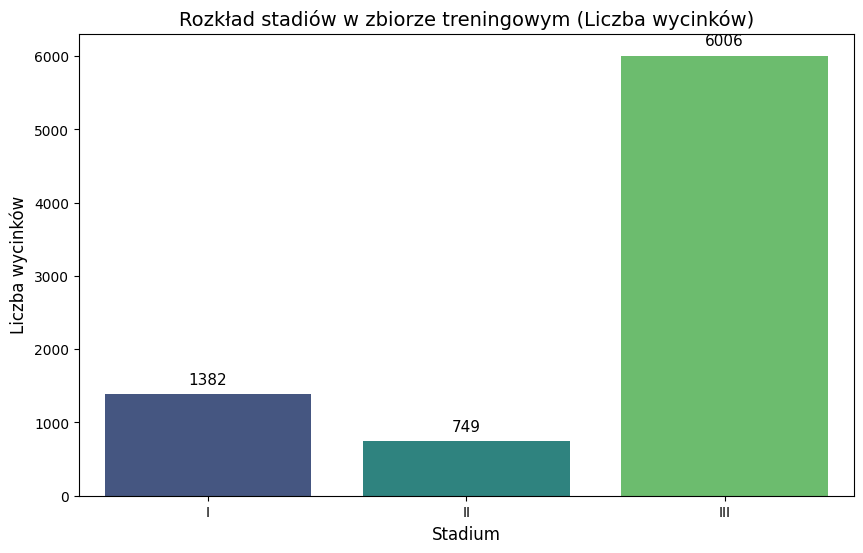


--- Przykładowe wycinki dla poszczególnych klas ---


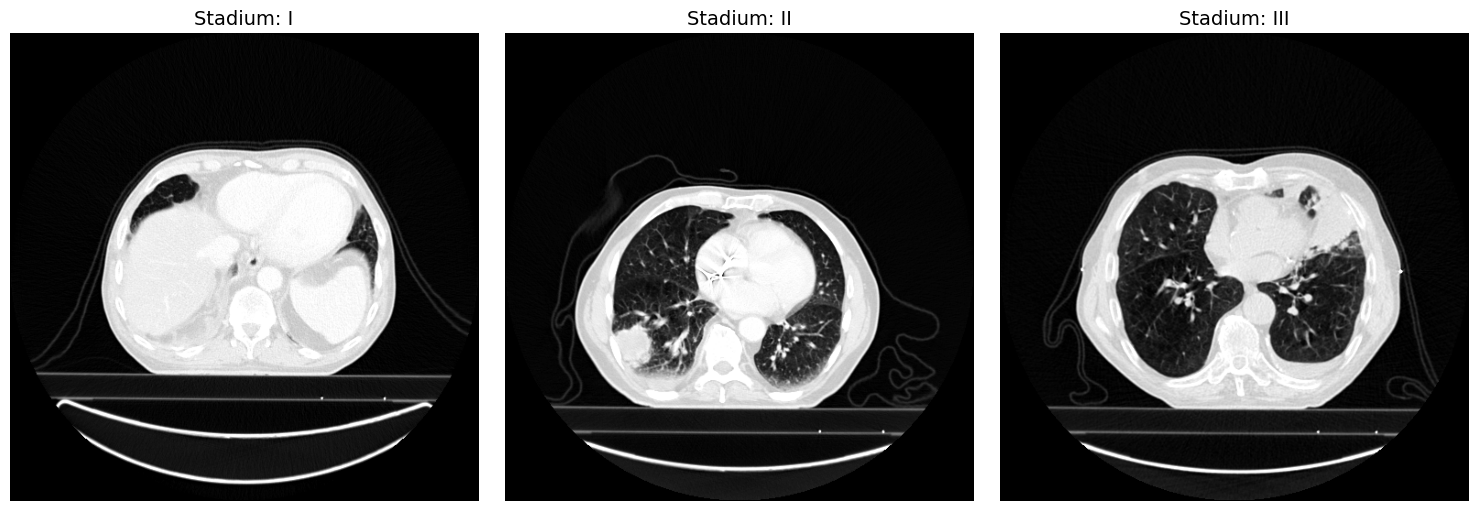

In [6]:
# Ścieżka do wypakowanego pliku train.csv
TRAIN_CSV = '/content/dataset/train.csv'

df_train = pd.read_csv(TRAIN_CSV)
df_train['merged_stage'] = df_train['original_stage'].replace({'IIIa': 'III', 'IIIb': 'III'})

# Statystyki klas w zbiorze treningowym
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_train, x='merged_stage', order=['I', 'II', 'III'], palette='viridis')
plt.title('Rozkład stadiów w zbiorze treningowym (Liczba wycinków)', fontsize=14)
plt.xlabel('Stadium', fontsize=12)
plt.ylabel('Liczba wycinków', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

# Wizualizacja przykładowych zdjęć dla każdej z 3 klas po połączeniu IIIa i IIIb
print("\n--- Przykładowe wycinki dla poszczególnych klas ---")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
stages = ['I', 'II', 'III']

for i, stage in enumerate(stages):
    sample_img_path = df_train[df_train['merged_stage'] == stage].iloc[0]['image_path']

    clean_path = sample_img_path.replace('\\', '/')
    filename = os.path.basename(clean_path)

    colab_img_path = os.path.join('/content/dataset/data_2d_full_slices', filename)

    img = Image.open(colab_img_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Stadium: {stage}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

EDA dla datasetu - demografia pacjentów, typy histologiczne i podział slice'ów pomiędzy pacjentami

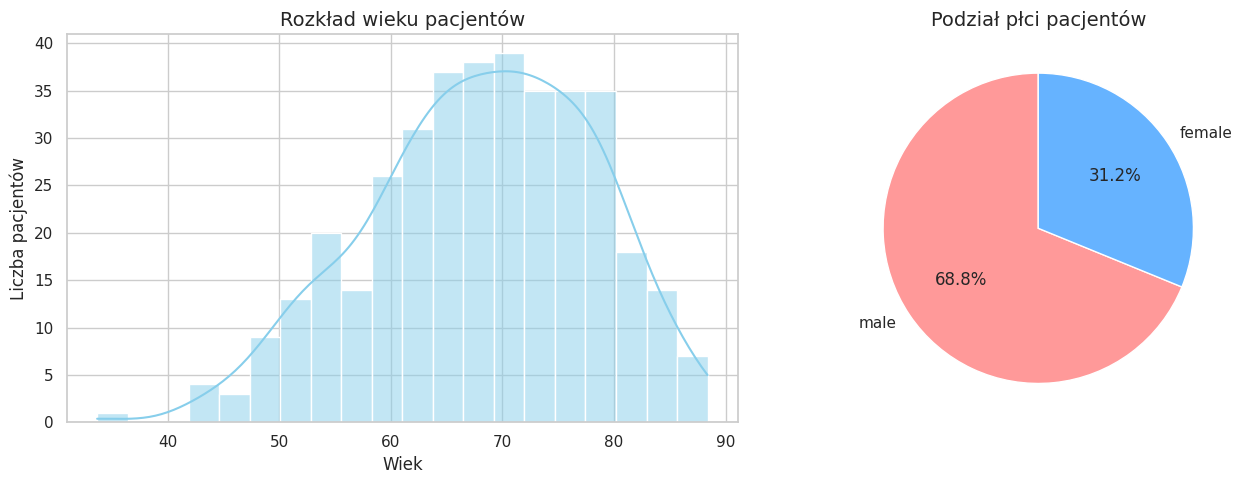

/tmp/ipykernel_13502/537504310.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_merged, y=histology_col, order=df_merged[histology_col].value_counts().index, palette='pastel')


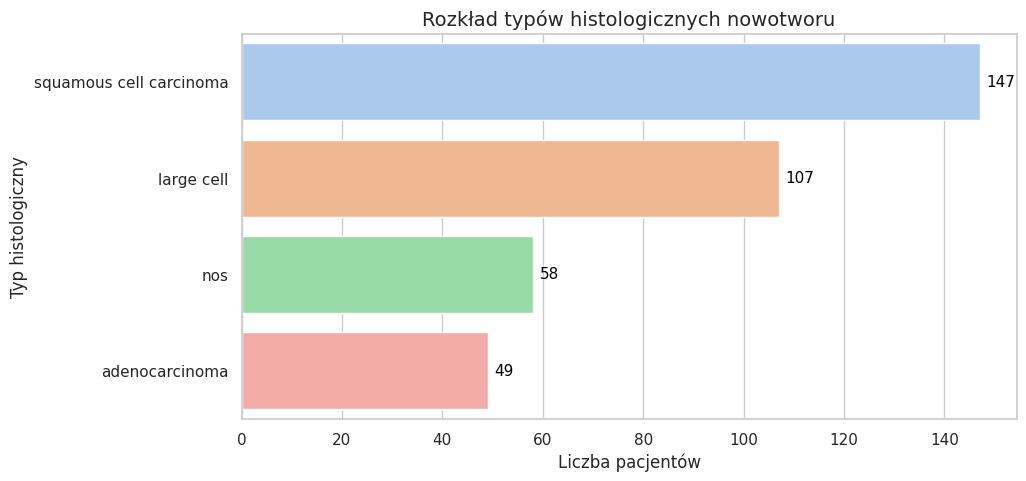

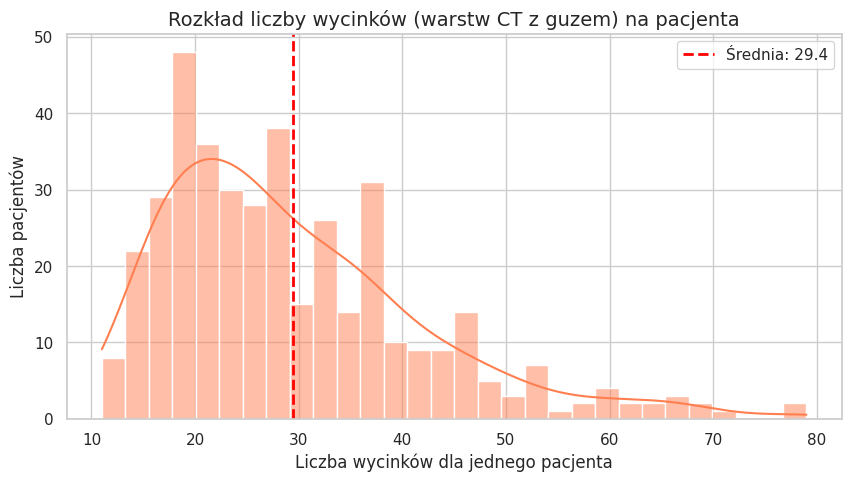

Całkowita liczba uwzględnionych pacjentów: 401
Średni wiek pacjenta: 68.1 lat (Min: 34, Max: 88)
Średnia liczba wycinków na pacjenta: 29.4
Pacjent z najmniejszą liczbą wycinków ma ich: 11
Pacjent z największą liczbą wycinków ma ich: 79


In [7]:

MASTER_CSV = r"/content/dataset/master_dataset.csv"
CLINICAL_CSV = r"/content/dataset/NSCLC-Radiomics-Lung1.clinical-data.csv"

df_master = pd.read_csv(MASTER_CSV)
df_clinical = pd.read_csv(CLINICAL_CSV)

df_clinical['PatientID'] = df_clinical['PatientID'].astype(str).str.strip()
df_master['patient_id'] = df_master['patient_id'].astype(str).str.strip()

df_merged = df_master[['patient_id']].drop_duplicates().merge(
    df_clinical, left_on='patient_id', right_on='PatientID', how='inner'
)

sns.set_theme(style="whitegrid")

# Demografia (Wiek i Płeć)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.histplot(data=df_merged, x='age', bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Rozkład wieku pacjentów', fontsize=14)
axes[0].set_xlabel('Wiek', fontsize=12)
axes[0].set_ylabel('Liczba pacjentów', fontsize=12)

gender_col = 'gender' if 'gender' in df_merged.columns else 'Gender' if 'Gender' in df_merged.columns else None

if gender_col:
    gender_counts = df_merged[gender_col].value_counts()
    axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
                startangle=90, colors=['#ff9999','#66b3ff'])
    axes[1].set_title('Podział płci pacjentów', fontsize=14)

plt.tight_layout()
plt.show()

# Typy Histologiczne
histology_col = 'Histology' if 'Histology' in df_merged.columns else 'histology' if 'histology' in df_merged.columns else None

if histology_col:
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(data=df_merged, y=histology_col, order=df_merged[histology_col].value_counts().index, palette='pastel')
    plt.title('Rozkład typów histologicznych nowotworu', fontsize=14)
    plt.xlabel('Liczba pacjentów', fontsize=12)
    plt.ylabel('Typ histologiczny', fontsize=12)

    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=11, color='black', xytext=(5, 0), textcoords='offset points')
    plt.show()

# Rozkład liczby warstw (wycinków) na pacjenta
plt.figure(figsize=(10, 5))
slices_per_patient = df_master.groupby('patient_id').size()

sns.histplot(slices_per_patient, bins=30, kde=True, color='coral')
plt.title('Rozkład liczby wycinków (warstw CT z guzem) na pacjenta', fontsize=14)
plt.xlabel('Liczba wycinków dla jednego pacjenta', fontsize=12)
plt.ylabel('Liczba pacjentów', fontsize=12)

mean_slices = slices_per_patient.mean()
plt.axvline(mean_slices, color='red', linestyle='dashed', linewidth=2, label=f'Średnia: {mean_slices:.1f}')
plt.legend()
plt.show()

print(f"Całkowita liczba uwzględnionych pacjentów: {len(df_merged)}")
print(f"Średni wiek pacjenta: {df_merged['age'].mean():.1f} lat (Min: {df_merged['age'].min():.0f}, Max: {df_merged['age'].max():.0f})")
print(f"Średnia liczba wycinków na pacjenta: {mean_slices:.1f}")
print(f"Pacjent z najmniejszą liczbą wycinków ma ich: {slices_per_patient.min()}")
print(f"Pacjent z największą liczbą wycinków ma ich: {slices_per_patient.max()}")

# PROTO - dodanie wieku i innych cech:



In [8]:
# Wczytanie i przygotowanie metadanych klinicznych
df_clinical = pd.read_csv('/content/dataset/NSCLC-Radiomics-Lung1.clinical-data.csv')

# Czyszczenie ID i przygotowanie cech
df_clinical['PatientID'] = df_clinical['PatientID'].astype(str).str.strip()

age_mean = df_clinical['age'].mean()
age_std = df_clinical['age'].std()
df_clinical['age_norm'] = (df_clinical['age'] - age_mean) / age_std

df_clinical['gender_bin'] = df_clinical['gender'].map({'male': 0.0, 'female': 1.0}).fillna(0.0)
clinical_features = df_clinical[['PatientID', 'age_norm', 'gender_bin']]

Preprocessing do ResNet

In [9]:
import torchvision.transforms as transforms

IMAGE_SIZE = 224

# Przekształcenia dla zbioru treningowego z augumentacją danych
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Przekształcenia dla zbiorów walidacyjnych i testowych
val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms gotowe! Sieć będzie pracować na znormalizowanych tensorach o rozmiarze 224x224.")

Transforms gotowe! Sieć będzie pracować na znormalizowanych tensorach o rozmiarze 224x224.


Klasa Dataset

In [10]:
class LungCancerHybridDataset(Dataset):
    def __init__(self, csv_file, clinical_df, root_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

        # Merge z danymi klinicznymi
        self.data_frame = self.data_frame.merge(
            clinical_df[['PatientID', 'age_norm', 'gender_bin']],
            left_on='patient_id', right_on='PatientID', how='left'
        )

        self.data_frame['age_norm'] = self.data_frame['age_norm'].fillna(0.0)
        self.data_frame['gender_bin'] = self.data_frame['gender_bin'].fillna(0.0)

        # Mapowanie etykiet
        label_col = 'original_stage' if 'original_stage' in self.data_frame.columns else 'label'
        self.data_frame['merged_label'] = self.data_frame[label_col].apply(merge_stage_label)

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        row = self.data_frame.iloc[idx]

        # Obraz
        filename = os.path.basename(row['image_path'].replace('\\', '/'))
        img_path = os.path.join(self.root_dir, filename)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Dane kliniczne (Wiek, Płeć)
        clinical_vec = torch.tensor([row['age_norm'], row['gender_bin']], dtype=torch.float32)

        # Etykieta
        label = int(row['merged_label'])

        return image, clinical_vec, label



DataLoaders i WeightedSampler


In [11]:
IMG_DIR_COLAB = '/content/dataset/data_2d_full_slices'

# Tworzenie instancji hybrydowych datasetów
train_dataset = LungCancerHybridDataset(csv_file='/content/dataset/train.csv',
                                        clinical_df=clinical_features,
                                        root_dir=IMG_DIR_COLAB,
                                        transform=train_transforms)

val_dataset = LungCancerHybridDataset(csv_file='/content/dataset/val.csv',
                                      clinical_df=clinical_features,
                                      root_dir=IMG_DIR_COLAB,
                                      transform=val_test_transforms)

test_dataset = LungCancerHybridDataset(csv_file='/content/dataset/test.csv',
                                       clinical_df=clinical_features,
                                       root_dir=IMG_DIR_COLAB,
                                       transform=val_test_transforms)

# Weighted Sampler - Balansowanie klas I, II, III
train_labels = train_dataset.data_frame['merged_label'].values
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = torch.from_numpy(class_weights[train_labels]).type(torch.DoubleTensor)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Weryfikacja
sample_batch = next(iter(train_loader))
print(f"Batch obrazów: {sample_batch[0].shape}")
print(f"Batch danych klinicznych: {sample_batch[1].shape}") # Powinno być [32, 2]
print(f"Batch etykiet: {sample_batch[2].shape}")
print("\nDane gotowe do treningu hybrydowego!")

Batch obrazów: torch.Size([32, 3, 224, 224])
Batch danych klinicznych: torch.Size([32, 2])
Batch etykiet: torch.Size([32])

Dane gotowe do treningu hybrydowego!


FocalLoss

In [12]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        if alpha is not None:
            self.register_buffer('alpha', alpha)
        else:
            self.alpha = None

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none',
                                  weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

Trening ResNet- 18

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")
if device.type == 'cpu':
    print("UWAGA: Trenujesz na procesorze! Zmień środowisko wykonawcze w Colabie na T4 GPU.")

# Definicja Architektury Hybrydowej (Obraz + Dane Kliniczne)
class ResNetHybrid(nn.Module):
    def __init__(self, num_classes=3, hidden_units=512, dropout_rate=0.24):
        super(ResNetHybrid, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity() # Usuwamy domyślną warstwę FC

        # Klasyfikator łączący 512 cech obrazu + 2 cechy kliniczne (wiek, płeć)
        self.classifier = nn.Sequential(
            nn.Linear(num_ftrs + 2, hidden_units),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, num_classes)
        )

    def forward(self, img, clinical):
        img_features = self.backbone(img)
        combined = torch.cat((img_features, clinical), dim=1)
        return self.classifier(combined)

# Inicjalizacja modelu hybrydowego i odmrażanie warstw
model = ResNetHybrid(num_classes=3, dropout_rate=0.4)

for param in model.parameters():
    param.requires_grad = False

# Odmrażamy tylko kluczowe warstwy dla specyficznych cech CT
for param in model.backbone.layer3.parameters():
    param.requires_grad = True
for param in model.backbone.layer4.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)

# Ustawienia optymalizatora z zróżnicowanym Learning Rate
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {'params': model.backbone.layer3.parameters(), 'lr': 1e-6},
    {'params': model.backbone.layer4.parameters(), 'lr': 5e-6},
    {'params': model.classifier.parameters(),     'lr': 1e-3}
], weight_decay=1e-3)

print("\nModel Hybrydowy ResNet-18 (Obraz + Dane Kliniczne) gotowy!")

Używane urządzenie: cuda

Model Hybrydowy ResNet-18 (Obraz + Dane Kliniczne) gotowy!


Pętla ucząca

Epoka 1/10
------------------------------
TRAIN Loss: 0.8825 | Acc: 0.5745 | F1: 0.5716 | AUC: 0.7678
VAL Loss: 0.8379 | Acc: 0.6371 | F1: 0.4364 | AUC: 0.6869
*** Nowy rekord AUC: 0.6869 ***

Epoka 2/10
------------------------------
TRAIN Loss: 0.5645 | Acc: 0.7595 | F1: 0.7585 | AUC: 0.9110
VAL Loss: 0.9570 | Acc: 0.6709 | F1: 0.4263 | AUC: 0.6860

Epoka 3/10
------------------------------
TRAIN Loss: 0.4111 | Acc: 0.8359 | F1: 0.8346 | AUC: 0.9501
VAL Loss: 1.0566 | Acc: 0.7343 | F1: 0.5236 | AUC: 0.7640
*** Nowy rekord AUC: 0.7640 ***

Epoka 4/10
------------------------------
TRAIN Loss: 0.3182 | Acc: 0.8758 | F1: 0.8756 | AUC: 0.9695
VAL Loss: 1.1029 | Acc: 0.6371 | F1: 0.4111 | AUC: 0.7013

Epoka 5/10
------------------------------
TRAIN Loss: 0.2377 | Acc: 0.9067 | F1: 0.9068 | AUC: 0.9826
VAL Loss: 1.2568 | Acc: 0.6600 | F1: 0.4381 | AUC: 0.7016

Epoka 6/10
------------------------------
TRAIN Loss: 0.2138 | Acc: 0.9175 | F1: 0.9169 | AUC: 0.9858
VAL Loss: 1.4341 | Acc: 0.654

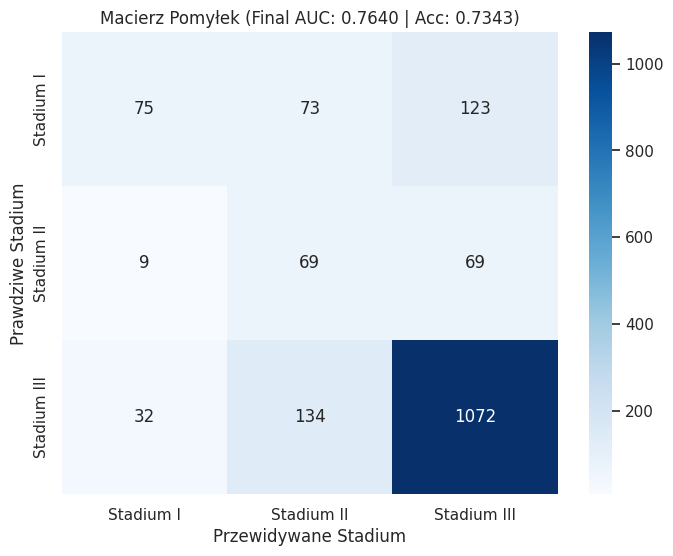

 Wyniki soft-voting na zbiorze walidacyjnym
 (Agregacja 2D -> 3D za pomocą Soft Voting)
PATIENT AUC: 0.7442 (Wynik referencyjny z publikacji: 0.881)
PATIENT ACC: 0.7333
              precision    recall  f1-score   support

   Stadium I       0.80      0.31      0.44        13
  Stadium II       0.33      0.50      0.40         6
 Stadium III       0.80      0.90      0.85        41

    accuracy                           0.73        60
   macro avg       0.65      0.57      0.57        60
weighted avg       0.76      0.73      0.72        60



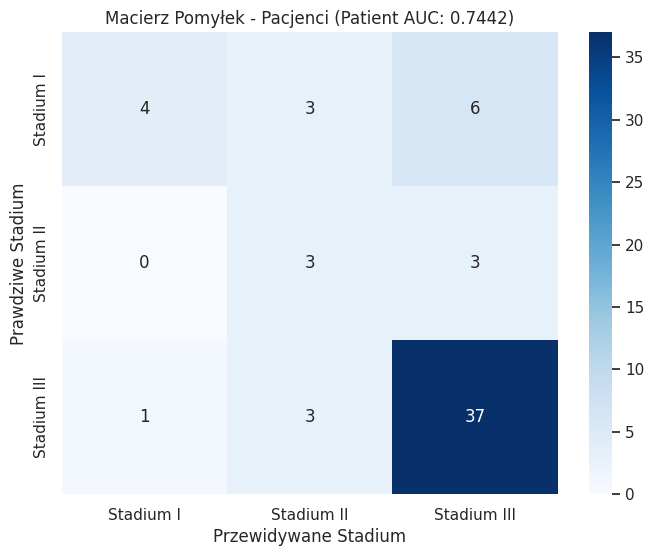

In [ ]:
# konfiguracja treninigu
target_names = ['Stadium I', 'Stadium II', 'Stadium III']
best_auc = 0.0
best_f1 = 0.0
best_acc = 0.0
results_path = 'best_metrics.txt'

with open(results_path, 'w') as f:
    f.write("REKORDY MODELU HYBRYDOWEGO (NSCLC STAGING)\n")

# Trenining hybrydowy
model = ResNetHybrid().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': [],
    'train_auc': [], 'val_auc': []
}

NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    print(f'Epoka {epoch+1}/{NUM_EPOCHS}')
    print('-' * 30)

    for phase in ['train', 'val']:
        model.train() if phase == 'train' else model.eval()
        dataloader = train_loader if phase == 'train' else val_loader

        running_loss = 0.0
        all_preds, all_labels, all_probs = [], [], []

        for inputs, clinical_data, labels in dataloader:
            inputs, clinical_data, labels = inputs.to(device), clinical_data.to(device), labels.to(device)

            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs, clinical_data)
                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = accuracy_score(all_labels, all_preds)
        epoch_f1 = f1_score(all_labels, all_preds, average='macro')
        try:
            epoch_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        except:
            epoch_auc = 0.0

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc)
        history[f'{phase}_f1'].append(epoch_f1)
        history[f'{phase}_auc'].append(epoch_auc)

        print(f'{phase.upper()} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | F1: {epoch_f1:.4f} | AUC: {epoch_auc:.4f}')

        if phase == 'val':
            if epoch_acc > best_acc:
                best_acc = epoch_acc
            if epoch_f1 > best_f1:
                best_f1 = epoch_f1
                torch.save(model.state_dict(), 'best_hybrid_f1.pth')
            if epoch_auc > best_auc:
                best_auc = epoch_auc
                torch.save(model.state_dict(), 'best_hybrid_auc.pth')
                print(f"*** Nowy rekord AUC: {best_auc:.4f} ***")
    print()

# Ewaluacja
print("\nRaport klasyfikacji")

model.load_state_dict(torch.load('best_hybrid_auc.pth'))
model.eval()

final_preds, final_labels, final_probs = [], [], []

with torch.no_grad():
    for inputs, clinical_data, labels in val_loader:
        inputs, clinical_data = inputs.to(device), clinical_data.to(device)
        outputs = model(inputs, clinical_data)

        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        final_preds.extend(preds.cpu().numpy())
        final_labels.extend(labels.cpu().numpy())
        final_probs.extend(probs.cpu().numpy())

final_auc = roc_auc_score(final_labels, final_probs, multi_class='ovr', average='macro')
final_acc = accuracy_score(final_labels, final_preds)

print(f"\nOstateczny wynik AUC: {final_auc:.4f}")
print(f"Ostateczny wynik Acc: {final_acc:.4f}")
print(f"Referencyjny wynik z publikacji (RF): 0.881")
print("\nSzczegółowy raport klasyfikacji:")
print(classification_report(final_labels, final_preds, target_names=target_names))

cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Macierz Pomyłek (Final AUC: {final_auc:.4f} | Acc: {final_acc:.4f})')
plt.ylabel('Prawdziwe Stadium')
plt.xlabel('Przewidywane Stadium')
plt.show()


# Soft-voting na poziomie pacjentów

df_val_results = val_dataset.data_frame.copy()

df_val_results['prob_I'] = [p[0] for p in final_probs]
df_val_results['prob_II'] = [p[1] for p in final_probs]
df_val_results['prob_III'] = [p[2] for p in final_probs]
df_val_results['true_label'] = final_labels

patient_level_df = df_val_results.groupby('patient_id').agg({
    'prob_I': 'mean',
    'prob_II': 'mean',
    'prob_III': 'mean',
    'true_label': 'first'
}).reset_index()

patient_probs = patient_level_df[['prob_I', 'prob_II', 'prob_III']].values
patient_preds = np.argmax(patient_probs, axis=1)
patient_true = patient_level_df['true_label'].values

patient_acc = accuracy_score(patient_true, patient_preds)
patient_auc = roc_auc_score(patient_true, patient_probs, multi_class='ovr', average='macro')

print(" Wyniki soft-voting na zbiorze walidacyjnym")
print(" (Agregacja 2D -> 3D za pomocą Soft Voting)")
print(f"PATIENT AUC: {patient_auc:.4f} (Wynik referencyjny z publikacji: 0.881)")
print(f"PATIENT ACC: {patient_acc:.4f}")
print(classification_report(patient_true, patient_preds, target_names=target_names))

cm_patient = confusion_matrix(patient_true, patient_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Macierz Pomyłek - Pacjenci (Patient AUC: {patient_auc:.4f})')
plt.ylabel('Prawdziwe Stadium')
plt.xlabel('Przewidywane Stadium')
plt.show()




# Historia

22.03.2026

Ilość epok: 10
Wartość treningowa: 0.9762
Wartość walidacyjna: 0.5550

Werdykt - Overfitting

--------------------------------------------------------------------------------

03.04.2026

Ilość epok: 25
Wartość treningowa: 0.
Wartość walidacyjna: 0.6021
F1: 0.4628

Werdykt: Overfitting

--------------------------------------------------------------------------------

Użyto weightedsamplera oraz klasę 3a i 3b połączono w jedną
10.04.2026

Epoki:10
Najlepsza dokładność walidacyjna (Val Acc): 0.7729
Najlepszy F1-score walidacyjny (Val F1): 0.5223

Werdykt - delikatny overfitting, z niezbalansowaniem klas

--------------------------------------------------------------------------------

Użyto GradientClipping + WeightedSampler

Epoki: 20
11.04.2026

Najlepsza dokładność walidacyjna (Val Acc): 0.7047
Najlepszy F1-score walidacyjny (Val F1): 0.4697


--------------------------------------------------------------------------------

Zgodnie z artykułem dodano dwie zmienne - wiek i płeć pacjenta oraz skupiono się na AUC zamiast f1
 -
Epoki: 10
11.04.2026

Krzywa uczenia i straty

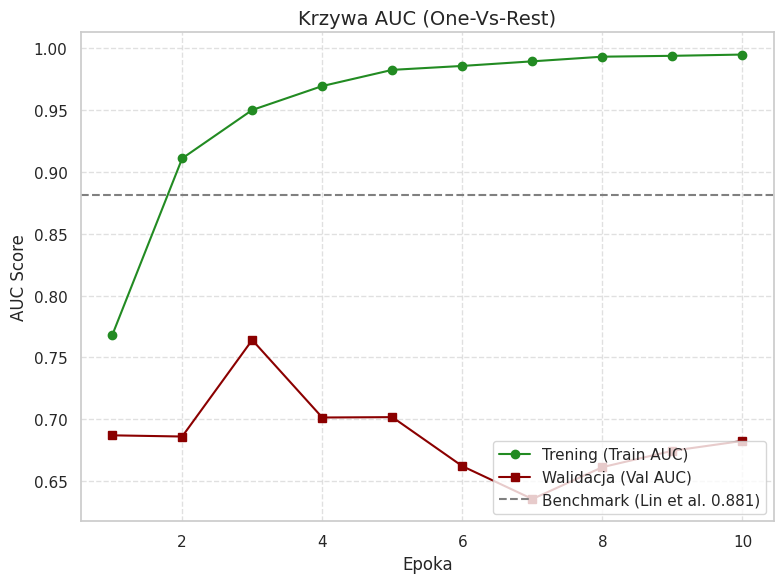

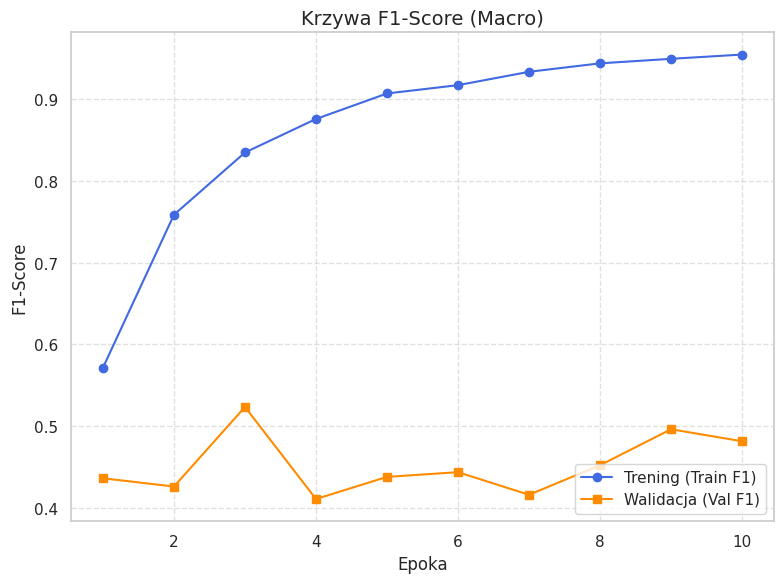

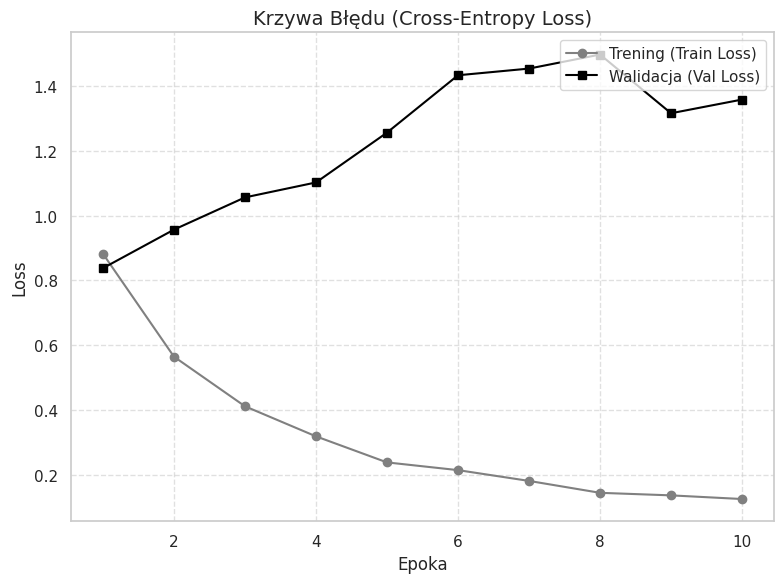

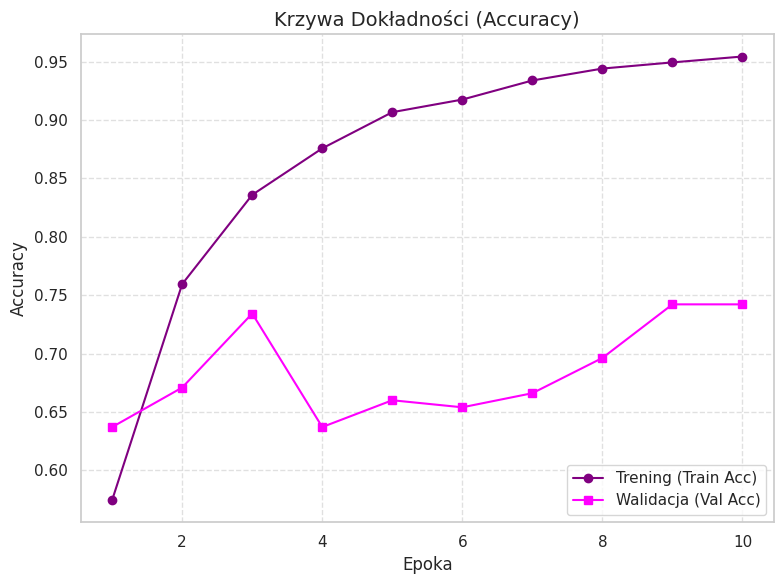

In [ ]:
epochs_range = range(1, len(history['train_f1']) + 1)

#  AUC
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history.get('train_auc', [0]*len(epochs_range)), label='Trening (Train AUC)', marker='o', color='forestgreen')
plt.plot(epochs_range, history.get('val_auc', [0]*len(epochs_range)), label='Walidacja (Val AUC)', marker='s', color='darkred')
plt.axhline(y=0.881, color='gray', linestyle='--', label='Benchmark (Lin et al. 0.881)')
plt.title('Krzywa AUC (One-Vs-Rest)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_auc.png', dpi=300, bbox_inches='tight')
plt.show()


# F1-Score (Macro Average)
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_f1'], label='Trening (Train F1)', marker='o', color='royalblue')
plt.plot(epochs_range, history['val_f1'], label='Walidacja (Val F1)', marker='s', color='darkorange')
plt.title('Krzywa F1-Score (Macro)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_f1.png', dpi=300, bbox_inches='tight')
plt.show()

# Funkcja błędu (Loss)
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history.get('train_loss', [0]*len(epochs_range)), label='Trening (Train Loss)', marker='o', color='gray')
plt.plot(epochs_range, history.get('val_loss', [0]*len(epochs_range)), label='Walidacja (Val Loss)', marker='s', color='black')
plt.title('Krzywa Błędu (Cross-Entropy Loss)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_loss.png', dpi=300, bbox_inches='tight')
plt.show()

# Accuracy (Dokładność)
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history.get('train_acc', [0]*len(epochs_range)), label='Trening (Train Acc)', marker='o', color='purple')
plt.plot(epochs_range, history.get('val_acc', [0]*len(epochs_range)), label='Walidacja (Val Acc)', marker='s', color='magenta')
plt.title('Krzywa Dokładności (Accuracy)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

Grad-Cam

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


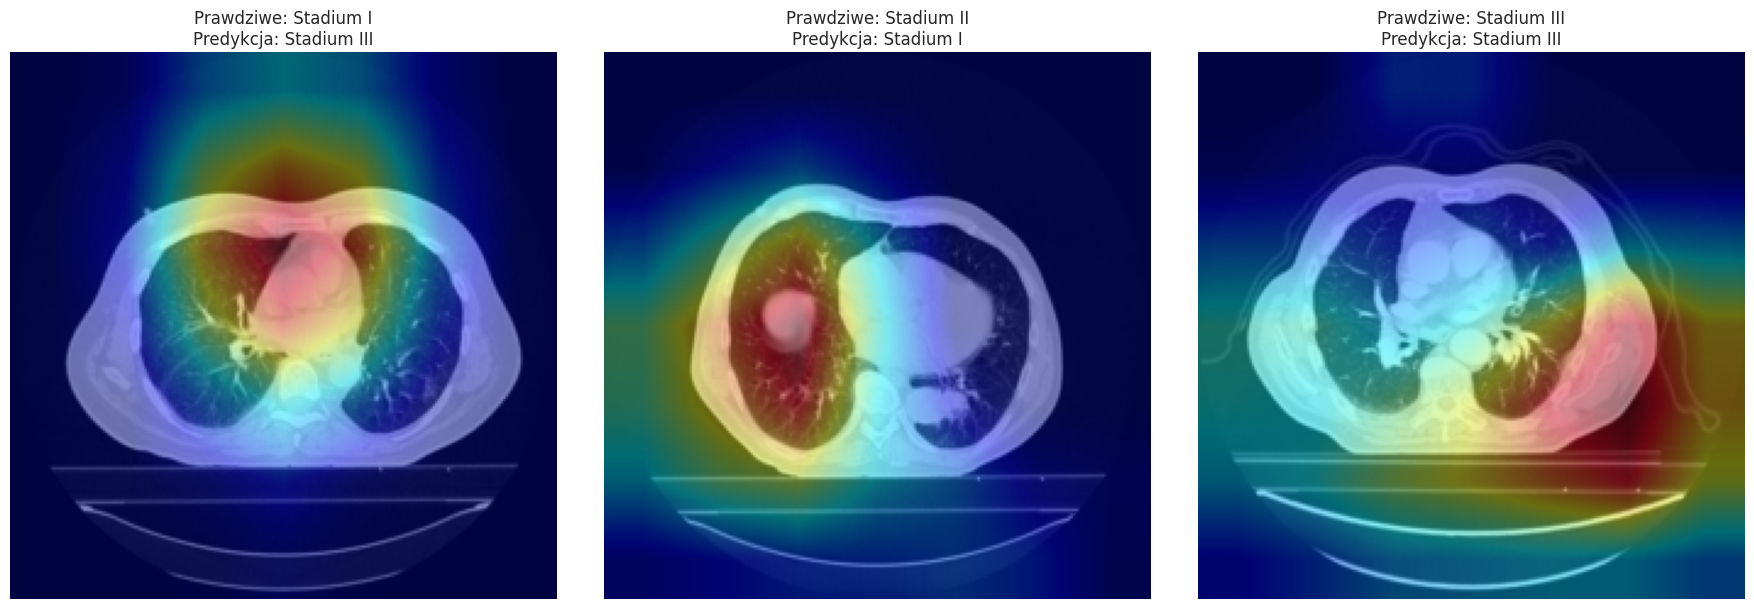

In [ ]:
def generate_gradcam(model, input_img, clinical_data, target_layer):
    model.eval()

    # Hooki do przechwytywania aktywacji i gradientów
    feature_blobs = []
    gradients = []

    def hook_feature(module, input, output):
        feature_blobs.append(output.cpu().data.numpy())

    def hook_gradient(module, grad_input, grad_output):
        gradients.append(grad_output[0].cpu().data.numpy())

    # Rejestracja hooków na ostatniej warstwie konwolucyjnej ResNet
    handle_forward = target_layer.register_forward_hook(hook_feature)
    handle_backward = target_layer.register_backward_hook(hook_gradient)

    # Forward pass
    output = model(input_img, clinical_data)
    _, target_class = torch.max(output, 1)

    # Backward pass dla wybranej klasy
    model.zero_grad()
    output[0, target_class].backward()

    # Wyznaczanie wag i mapy ciepła
    grads = gradients[0]
    weights = np.mean(grads, axis=(2, 3))[0]
    features = feature_blobs[0][0]

    cam = np.zeros(features.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * features[i, :, :]

    # Postprocessing mapy ciepła
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam))

    handle_forward.remove()
    handle_backward.remove()

    return cam, target_class.item()

def show_gradcam_gallery(model, dataset):
    # Szukamy po jednym przykładzie dla każdego stadium (0, 1, 2)
    indices = []
    for target_label in [0, 1, 2]:
        for i in range(len(dataset)):
            _, _, label = dataset[i]
            if label == target_label:
                indices.append(i)
                break

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    target_names = ['Stadium I', 'Stadium II', 'Stadium III']

    for i, idx in enumerate(indices):
        img_tensor, clinical_tensor, label = dataset[idx]

        # Przygotowanie do Grad-CAM
        input_img = img_tensor.unsqueeze(0).to(device)
        clinical_data = clinical_tensor.unsqueeze(0).to(device)

        # Generowanie mapy (celujemy w layer4 backbone'u)
        heatmap, pred_class = generate_gradcam(model, input_img, clinical_data, model.backbone.layer4)

        # Przygotowanie obrazu do wyświetlenia
        img_show = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())

        # Nałożenie mapy ciepła
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
        overlay = 0.6 * img_show + 0.4 * heatmap_color

        axes[i].imshow(overlay)
        axes[i].set_title(f"Prawdziwe: {target_names[label]}\nPredykcja: {target_names[pred_class]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Wywołanie
show_gradcam_gallery(model, val_dataset)

# Optuna


Tutaj celujemy w usprawnienie F1 jako metryki dla slice'ów

In [ ]:
EPOCHS_PER_TRIAL = 15

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2)

def objective(trial):
    # Hiperparametry
    lr_fc        = trial.suggest_float("lr_fc",        1e-4, 2e-3, log=True)
    lr_layer4    = trial.suggest_float("lr_layer4",    1e-6, 1e-5, log=True)
    lr_layer3    = trial.suggest_float("lr_layer3",    1e-7, 5e-6, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.3,  0.6)
    w2           = trial.suggest_float("weight_stage2", 2.0, 6.0)


    model = ResNetHybrid(num_classes=3, dropout_rate=dropout_rate).to(device)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.backbone.layer3.parameters():
        param.requires_grad = True
    for param in model.backbone.layer4.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

    # Loss i optimizer
    criterion = FocalLoss(alpha=torch.FloatTensor([1.53, w2, 0.49]), gamma=2).to(device)
    optimizer = optim.Adam([
        {'params': model.backbone.layer3.parameters(), 'lr': lr_layer3},
        {'params': model.backbone.layer4.parameters(), 'lr': lr_layer4},
        {'params': model.classifier.parameters(),      'lr': lr_fc}
    ], weight_decay=weight_decay)

    # Pętla treningowa
    for epoch in range(EPOCHS_PER_TRIAL):
        model.train()
        for inputs, clinical_data, labels in train_loader:
            inputs       = inputs.to(device)
            clinical_data = clinical_data.to(device)
            labels       = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs, clinical_data)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # Ewaluacja
        model.eval()
        all_labels, all_preds = [], []

        with torch.no_grad():
            for inputs, clinical_data, labels in val_loader:
                inputs        = inputs.to(device)
                clinical_data = clinical_data.to(device)

                outputs = model(inputs, clinical_data)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_f1 = f1_score(all_labels, all_preds, average='macro')
        print(f"  Trial {trial.number} | Epoka {epoch+1}/{EPOCHS_PER_TRIAL} | F1: {val_f1:.4f}")

        trial.report(val_f1, epoch)
        if trial.should_prune():
            print(f"  Trial {trial.number} przerwany.")
            raise optuna.exceptions.TrialPruned()

    return val_f1

# Start
study = optuna.create_study(
    direction="maximize",
    study_name="ResNetHybrid_Opt_v2",
    storage="sqlite:////content/drive/MyDrive/optuna_study_v2.db",
    load_if_exists=False,
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)
study.optimize(objective, n_trials=25)

print(f"Najlepszy Slice F1-Macro: {study.best_value:.4f}")
print("Najlepsze parametry:")
with open('best_optuna_params.json', 'w') as fp:
    json.dump(study.best_params, fp)

print("Najlepsze parametry zapisano do JSON")

for k, v in study.best_params.items():
    print(f"  {k}: {v}")



[I 2026-04-13 09:07:03,849] A new study created in RDB with name: ResNetHybrid_Opt_v2


  Trial 0 | Epoka 1/15 | F1: 0.2563
  Trial 0 | Epoka 2/15 | F1: 0.3643
  Trial 0 | Epoka 3/15 | F1: 0.1417
  Trial 0 | Epoka 4/15 | F1: 0.3274
  Trial 0 | Epoka 5/15 | F1: 0.2994
  Trial 0 | Epoka 6/15 | F1: 0.3621
  Trial 0 | Epoka 7/15 | F1: 0.3981
  Trial 0 | Epoka 8/15 | F1: 0.3491
  Trial 0 | Epoka 9/15 | F1: 0.3307
  Trial 0 | Epoka 10/15 | F1: 0.3499
  Trial 0 | Epoka 11/15 | F1: 0.3666
  Trial 0 | Epoka 12/15 | F1: 0.4071
  Trial 0 | Epoka 13/15 | F1: 0.3760
  Trial 0 | Epoka 14/15 | F1: 0.2301


[I 2026-04-13 09:26:39,044] Trial 0 finished with value: 0.3640317158219976 and parameters: {'lr_fc': 0.00019802226161692036, 'lr_layer4': 2.1574820875814365e-06, 'lr_layer3': 1.6846480441577742e-06, 'weight_decay': 0.009549081040269624, 'dropout_rate': 0.5312639684961143, 'weight_stage2': 3.0822363910704396}. Best is trial 0 with value: 0.3640317158219976.


  Trial 0 | Epoka 15/15 | F1: 0.3640
  Trial 1 | Epoka 1/15 | F1: 0.0980
  Trial 1 | Epoka 2/15 | F1: 0.1730
  Trial 1 | Epoka 3/15 | F1: 0.2948
  Trial 1 | Epoka 4/15 | F1: 0.3016
  Trial 1 | Epoka 5/15 | F1: 0.2359
  Trial 1 | Epoka 6/15 | F1: 0.2079
  Trial 1 | Epoka 7/15 | F1: 0.3249
  Trial 1 | Epoka 8/15 | F1: 0.2189
  Trial 1 | Epoka 9/15 | F1: 0.2885
  Trial 1 | Epoka 10/15 | F1: 0.2399
  Trial 1 | Epoka 11/15 | F1: 0.2547
  Trial 1 | Epoka 12/15 | F1: 0.2899
  Trial 1 | Epoka 13/15 | F1: 0.3297
  Trial 1 | Epoka 14/15 | F1: 0.4100


[I 2026-04-13 09:46:08,841] Trial 1 finished with value: 0.34320138846035975 and parameters: {'lr_fc': 0.0002063958495737444, 'lr_layer4': 3.2161906174741605e-06, 'lr_layer3': 4.950537850445422e-07, 'weight_decay': 0.0006947826888075315, 'dropout_rate': 0.44147825521203266, 'weight_stage2': 4.116594208315053}. Best is trial 0 with value: 0.3640317158219976.


...

  Trial 3 | Epoka 15/15 | F1: 0.3837
  Trial 4 | Epoka 1/15 | F1: 0.2445
  Trial 4 | Epoka 2/15 | F1: 0.2899
  Trial 4 | Epoka 3/15 | F1: 0.2061
  Trial 4 | Epoka 4/15 | F1: 0.2577
  Trial 4 | Epoka 5/15 | F1: 0.2937
  Trial 4 | Epoka 6/15 | F1: 0.4113
  Trial 4 | Epoka 7/15 | F1: 0.2837
  Trial 4 | Epoka 8/15 | F1: 0.3502
  Trial 4 | Epoka 9/15 | F1: 0.3709
  Trial 4 | Epoka 10/15 | F1: 0.3569
  Trial 4 | Epoka 11/15 | F1: 0.2876
  Trial 4 | Epoka 12/15 | F1: 0.3303
  Trial 4 | Epoka 13/15 | F1: 0.3443
  Trial 4 | Epoka 14/15 | F1: 0.4267


[I 2026-04-13 10:44:23,034] Trial 4 finished with value: 0.3132492006627448 and parameters: {'lr_fc': 0.0009353530468099102, 'lr_layer4': 3.2355645991018896e-06, 'lr_layer3': 2.1349418683098004e-07, 'weight_decay': 0.0001983783643264279, 'dropout_rate': 0.3960027454534587, 'weight_stage2': 2.8121302910975325}. Best is trial 2 with value: 0.4257750625940653.


  Trial 4 | Epoka 15/15 | F1: 0.3132
  Trial 5 | Epoka 1/15 | F1: 0.3520
  Trial 5 | Epoka 2/15 | F1: 0.2616
  Trial 5 | Epoka 3/15 | F1: 0.3273
  Trial 5 | Epoka 4/15 | F1: 0.3554
  Trial 5 | Epoka 5/15 | F1: 0.3152


[I 2026-04-13 10:52:12,947] Trial 5 pruned. 


  Trial 5 | Epoka 6/15 | F1: 0.2989
  Trial 5 przerwany.
  Trial 6 | Epoka 1/15 | F1: 0.1315
  Trial 6 | Epoka 2/15 | F1: 0.3944
  Trial 6 | Epoka 3/15 | F1: 0.1832
  Trial 6 | Epoka 4/15 | F1: 0.3945
  Trial 6 | Epoka 5/15 | F1: 0.2738
  Trial 6 | Epoka 6/15 | F1: 0.2521
  Trial 6 | Epoka 7/15 | F1: 0.3035
  Trial 6 | Epoka 8/15 | F1: 0.3671


Finałowy trening oraz soft-voting

In [ ]:

# FINALNY TRENING — ResNetHybrid z best_params z Optuny

best_params = study.best_trial.params
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
target_names = ['Stadium I', 'Stadium II', 'Stadium III']

print(f"Urządzenie: {device}")
print(f"Najlepsze parametry z Optuny: {best_params}\n")

model = ResNetHybrid(
    num_classes=3,
    hidden_units=best_params.get('hidden_units', 256),
    dropout_rate=best_params.get('dropout_rate', 0.4)
).to(device)

for param in model.parameters():
    param.requires_grad = False
for param in model.backbone.layer3.parameters():
    param.requires_grad = True
for param in model.backbone.layer4.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

# Loss z wagami z Optuny
alpha = torch.FloatTensor([1.53, best_params.get('weight_stage2', 4.0), 0.49]).to(device)
criterion = FocalLoss(alpha=alpha, gamma=2).to(device)

# Optimizer z LR z Optuny
optimizer = optim.Adam([
    {'params': model.backbone.layer3.parameters(), 'lr': best_params.get('lr_layer3', 1e-7)},
    {'params': model.backbone.layer4.parameters(), 'lr': best_params.get('lr_layer4', 1e-5)},
    {'params': model.classifier.parameters(),      'lr': best_params.get('lr_fc',     1e-3)}
], weight_decay=best_params.get('weight_decay', 1e-3))

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.2, patience=4, verbose=True
)

# Zmienne kontrolne
NUM_EPOCHS     = 40
PATIENCE       = 10
best_val_auc   = 0.0
best_val_f1    = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
patience_counter = 0

history = {
    'train_loss': [], 'val_loss': [],
    'train_auc':  [], 'val_auc':  [],
    'train_f1':   [], 'val_f1':   [],
    'train_acc':  [], 'val_acc':  []
}

print("="*65)
print(f"{'Epoka':<6} {'T-Loss':<8} {'V-Loss':<8} {'V-AUC':<8} {'V-F1':<7} {'V-Acc':<7} {'Best-AUC':<10} {'Best-F1'}")
print("="*65)

for epoch in range(NUM_EPOCHS):

    # Trening
    model.train()
    running_loss = 0.0
    all_labels, all_probs, all_preds = [], [], []

    for inputs, clinical, labels in train_loader:
        inputs   = inputs.to(device)
        clinical = clinical.to(device)
        labels   = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs, clinical)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

    train_loss = running_loss / len(train_loader.dataset)
    train_auc  = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    train_f1   = f1_score(all_labels, all_preds, average='macro')
    train_acc  = accuracy_score(all_labels, all_preds)

    # Walidacja
    model.eval()
    v_loss = 0.0
    v_labels, v_preds, v_probs = [], [], []

    with torch.no_grad():
        for inputs, clinical, labels in val_loader:
            inputs   = inputs.to(device)
            clinical = clinical.to(device)
            labels   = labels.to(device)

            outputs = model(inputs, clinical)
            loss    = criterion(outputs, labels)

            v_loss += loss.item() * inputs.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            v_labels.extend(labels.cpu().numpy())
            v_preds.extend(preds.cpu().numpy())
            v_probs.extend(probs.cpu().numpy())

    val_loss = v_loss / len(val_loader.dataset)
    val_auc  = roc_auc_score(v_labels, v_probs, multi_class='ovr', average='macro')
    val_f1   = f1_score(v_labels, v_preds, average='macro')
    val_acc  = accuracy_score(v_labels, v_preds)

    # Zapis do historii
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"E{epoch+1:02}   | {train_loss:<8.3f} {val_loss:<8.3f} {val_auc:<8.4f} {val_f1:<7.3f} {val_acc:<7.3f} {best_val_auc:<10.4f} {best_val_f1:.4f}")
    scheduler.step(val_auc)

    # Najlepszy model
    if val_auc > best_val_auc:
        best_val_auc   = val_auc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), '/content/best_hybrid_final.pth')
        patience_counter = 0
        print(f"      ✓ Nowy najlepszy model zapisany (AUC: {best_val_auc:.4f})")
    else:
        patience_counter += 1

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1

    # Early Stopping
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping — brak poprawy AUC przez {PATIENCE} epok.")
        break

print(f"Trening zakończony | Najlepszy Val AUC: {best_val_auc:.4f} | Najlepszy Val F1: {best_val_f1:.4f}")

#Eval na zbiorze testowym
model.load_state_dict(best_model_wts)
model.eval()

test_labels, test_preds, test_probs = [], [], []

with torch.no_grad():
    for inputs, clinical, labels in test_loader:
        inputs   = inputs.to(device)
        clinical = clinical.to(device)

        outputs = model(inputs, clinical)
        probs   = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        test_labels.extend(labels.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

slice_f1  = f1_score(test_labels, test_preds, average='macro')
slice_auc = roc_auc_score(test_labels, test_probs, multi_class='ovr', average='macro')
slice_acc = accuracy_score(test_labels, test_preds)

print("WYNIKI (przed votingiem)")
print(f"AUC: {slice_auc:.4f} | F1: {slice_f1:.4f} | Acc: {slice_acc:.4f}")
print(classification_report(test_labels, test_preds, target_names=target_names, digits=4))

# Soft-Voting
df_test_results = test_dataset.data_frame.copy()
df_test_results['prob_I']      = [p[0] for p in test_probs]
df_test_results['prob_II']     = [p[1] for p in test_probs]
df_test_results['prob_III']    = [p[2] for p in test_probs]
df_test_results['true_label']  = test_labels

patient_level_df = df_test_results.groupby('patient_id').agg({
    'prob_I':      'mean',
    'prob_II':     'mean',
    'prob_III':    'mean',
    'true_label':  'first'
}).reset_index()

patient_probs_arr = patient_level_df[['prob_I', 'prob_II', 'prob_III']].values
patient_preds     = np.argmax(patient_probs_arr, axis=1)
patient_true      = patient_level_df['true_label'].values

patient_f1  = f1_score(patient_true, patient_preds, average='macro')
patient_auc = roc_auc_score(patient_true, patient_probs_arr, multi_class='ovr', average='macro')
patient_acc = accuracy_score(patient_true, patient_preds)

print("WYNIKI (soft voting)")
print(f"AUC: {patient_auc:.4f} | F1: {patient_f1:.4f} | Acc: {patient_acc:.4f}")
print(f"\nBenchmark publikacji: AUC 0.881")
print(f"Różnica do benchmarku: {0.881 - patient_auc:+.4f}")
print(classification_report(patient_true, patient_preds, target_names=target_names, digits=4))

# Macierz pomyłek na poziomie pacjentów
cm_patient = confusion_matrix(patient_true, patient_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Przewidywane Stadium')
plt.ylabel('Rzeczywiste Stadium')
plt.title(f'Macierz Pomyłek — Patient Level\nAUC: {patient_auc:.4f} | F1: {patient_f1:.4f}')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_patient_final.png', dpi=300)
plt.show()

Wykresy dla zbioru TRAIN i VAL

In [ ]:
epochs_range = range(1, len(history['train_loss']) + 1)

# AUC
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_auc'], label='Trening (Train AUC)', marker='o', color='forestgreen')
plt.plot(epochs_range, history['val_auc'], label='Walidacja (Val AUC)', marker='s', color='darkred')
plt.axhline(y=0.881, color='gray', linestyle='--', label='Benchmark (Lin et al. 0.881)')
plt.title('Krzywa AUC w procesie uczenia', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/final_hybrid_auc.png', dpi=300, bbox_inches='tight')
plt.show()

# F1-Score
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_f1'], label='Trening (Train F1)', marker='o', color='royalblue')
plt.plot(epochs_range, history['val_f1'], label='Walidacja (Val F1)', marker='s', color='darkorange')
plt.title('Krzywa F1-Score (Macro) w procesie uczenia', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/final_hybrid_f1.png', dpi=300, bbox_inches='tight')
plt.show()

# Loss
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_loss'], label='Trening (Train Loss)', marker='o', color='gray')
plt.plot(epochs_range, history['val_loss'], label='Walidacja (Val Loss)', marker='s', color='black')
plt.title('Krzywa Błędu (Focal Loss)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/final_hybrid_loss.png', dpi=300, bbox_inches='tight')
plt.show()

# Accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_acc'], label='Trening (Train Acc)', marker='o', color='purple')
plt.plot(epochs_range, history['val_acc'], label='Walidacja (Val Acc)', marker='s', color='magenta')
plt.title('Krzywa Dokładności (Accuracy) w procesie uczenia', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/final_hybrid_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

Grad-cam

In [ ]:
class HybridModelWrapper(torch.nn.Module):
    def __init__(self, model, clinical_data):
        super().__init__()
        self.model = model
        self.clinical_data = clinical_data

    def forward(self, x):
        return self.model(x, self.clinical_data)

# Szukamy po 1 przykładzie dla każdej z 3 klas
examples = {0: [], 1: [], 2: []}
samples_per_class = 1

model.eval()
with torch.no_grad():
    for inputs, clinical, labels in test_loader:
        for i in range(len(labels)):
            lbl = labels[i].item()
            if len(examples[lbl]) < samples_per_class:
                single_img = inputs[i].unsqueeze(0).to(device)
                single_clin = clinical[i].unsqueeze(0).to(device)
                examples[lbl].append((single_img, single_clin))

        if all(len(v) == samples_per_class for v in examples.values()):
            break

# Konfiguracja Grad-CAM
target_layers = [model.backbone.layer4[-1]]
target_names = ['Stadium I', 'Stadium II', 'Stadium III']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Analiza Grad-CAM na zbiorze testowym (Obrazy CT)', fontsize=16, y=1.05)

# Generowanie map aktywacji
for class_idx in range(3):
    img_tensor, clin_tensor = examples[class_idx][0]
    wrapped_model = HybridModelWrapper(model, clin_tensor)
    cam = GradCAM(model=wrapped_model, target_layers=target_layers)
    targets = [ClassifierOutputTarget(class_idx)]

    # Generowanie mapy
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    # Przygotowanie obrazu
    rgb_img = img_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    ax = axes[class_idx]
    ax.imshow(cam_image)
    ax.set_title(f"Prawdziwa klasa: {target_names[class_idx]}", fontsize=14)
    ax.axis('off')

plt.tight_layout()
# Zapis
plt.savefig('/content/final_hybrid_gradcam_test.png', dpi=300, bbox_inches='tight')
plt.show()